In [21]:
! pip install gwpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.0/777.0 kB 95.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


In [1]:
from gwpy.timeseries import TimeSeries
gwpy_strain = TimeSeries.read('challenge1.gwf', channel="H1:CHALLENGE1")

/opt/conda/lib/python3.8/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(True)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
print(gwpy_strain) #checking the data by printing it

data_gwpy = gwpy_strain #renaming the data

TimeSeries([ 1.09389188e-21,  1.21228706e-22,  1.64565889e-24,
            ..., -4.43135131e-23, -2.34576855e-22,
             4.51019899e-22]
           unit: ct,
           t0: -64.0 s,
           dt: 0.000244140625 s,
           name: H1:CHALLENGE1,
           channel: None)


In [3]:
sampling_rate = 1.0/data_gwpy.dt #calculating the sampling rate

print(sampling_rate)

4096.0 1 / s


In [4]:
data_gwpy.duration #getting the duration of the data

<Quantity 128. s>

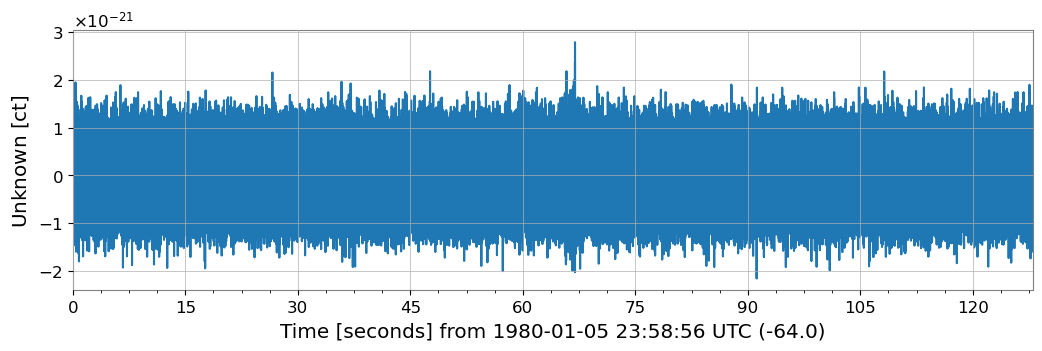

In [5]:
plot = data_gwpy.plot() #plotting the data in the time domain, x = 0 corresponds to t = -64


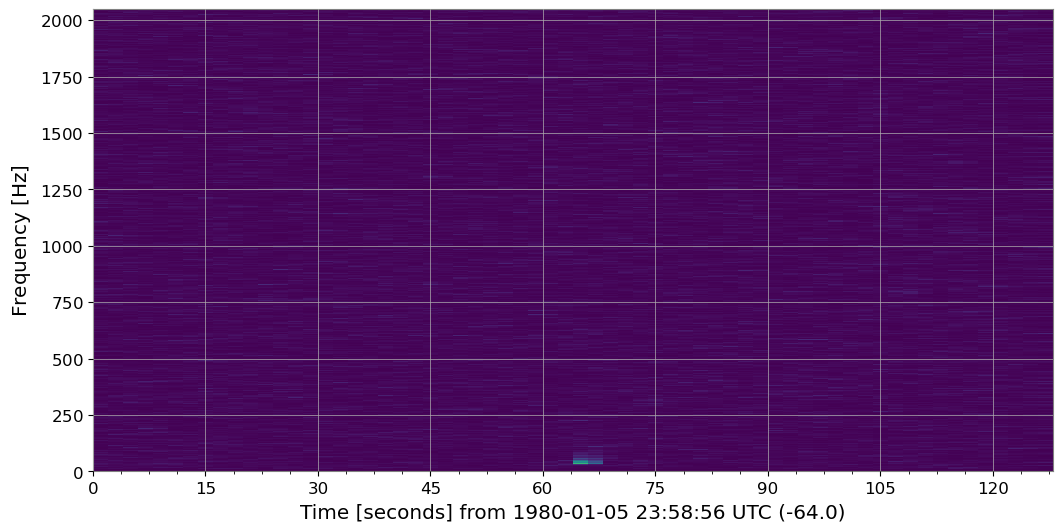

In [6]:
spectrogram = data_gwpy.spectrogram2(fftlength = 4,overlap = 2)

specplot = spectrogram.plot() #making spectrogram plot, but have to  fix it now.

In [7]:
spectrogram.min() #check min and max of the data

<Quantity 4.05860196e-58 ct2 / Hz>

In [8]:
spectrogram.max()

<Quantity 5.89663526e-45 ct2 / Hz>

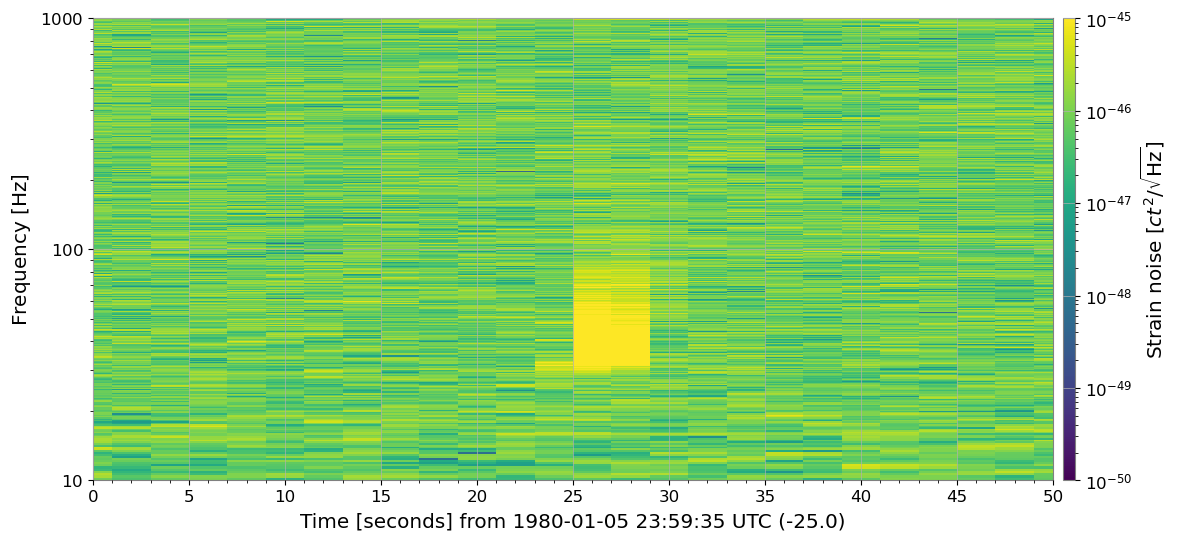

In [9]:
ax = specplot.gca()
ax.set_xlim(-25, 25) #adjusting the x range
ax.set_yscale('log') #logarithmic y scale
ax.set_ylim(10, 1000)
ax.colorbar(         #adjusting the colour bar to fit the values of the data
    clim=(1e-50, 1e-45),
    norm="log",
    label=r"Strain noise [$ct^2/\sqrt{\mathrm{Hz}}$]",
)
specplot  # refresh

#as can been seen in the spectrogram, the signal starts roughly around t = 0 and ends around t = 4